# Regresja liniowa

Notebook pokazuje najprostszy pelny proces:
1. import bibliotek
2. wczytanie danych CSV
3. sprawdzenie danych
4. podzial na trening i test
5. trenowanie modelu
6. predykcja
7. wykres: ceny rzeczywiste vs przewidywane
8. testowanie modelu dla recznie podanych parametrow

## 1) Import bibliotek

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


## 2) Wczytanie danych

In [21]:
df = pd.read_csv("a.csv",sep=';',decimal=',')
df.head()

,metraz_m2,pietro,rok_budowy,standard,odleglosc_km,cena_tys_pln
0,79,5,1990,5,4.8,963
1,45,9,2016,5,9.2,643
2,73,9,2009,3,9.2,847
3,62,3,2010,3,7.2,723
4,52,2,2007,3,13.2,573


## 3) Sprawdzenie wczytanych danych

In [22]:
print("Rozmiar danych:", df.shape)
print("\nTypy kolumn:")
print(df.dtypes)
print("\nPodstawowe statystyki:")
df.describe()

print(df.columns)

Rozmiar danych: (120, 6)

Typy kolumn:
metraz_m2         int64
pietro            int64
rok_budowy        int64
standard          int64
odleglosc_km    float64
cena_tys_pln      int64
dtype: object

Podstawowe statystyki:
Index(['metraz_m2', 'pietro', 'rok_budowy', 'standard', 'odleglosc_km',
       'cena_tys_pln'],
      dtype='str')


## 4) Podzial na dane treningowe i testowe

In [23]:
feature_cols = ['metraz_m2', 'pietro', 'rok_budowy', 'standard', 'odleglosc_km']
X = df[feature_cols]
y = df["cena_tys_pln"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (90, 5) X_test: (30, 5)


## 5) Trenowanie modelu

In [24]:
def build_model(degree=None):
    if degree is None:
        return LinearRegression()
    else:
        return Pipeline([
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("model", LinearRegression())
        ])

In [28]:

model = build_model()   # regresja kwadratowa

model.fit(X_train, y_train)

print("Model wytrenowany.")

Model wytrenowany.


## 6) Predykcja i prosta ocena modelu

In [29]:
y_pred = model.predict(X_test)
r2 = model.score(X_test, y_test)
print(f"R2 na zbiorze testowym: {r2:.4f}")

porownanie = pd.DataFrame({"cena_rzeczywista": y_test.values, "cena_przewidywana": y_pred})
porownanie.head()

R2 na zbiorze testowym: 0.9522


,cena_rzeczywista,cena_przewidywana
0,958,943.566032
1,709,736.888773
2,573,547.814792
3,688,700.229393
4,506,529.368563


## 7) Wykres: predykcja i ceny rzeczywiste

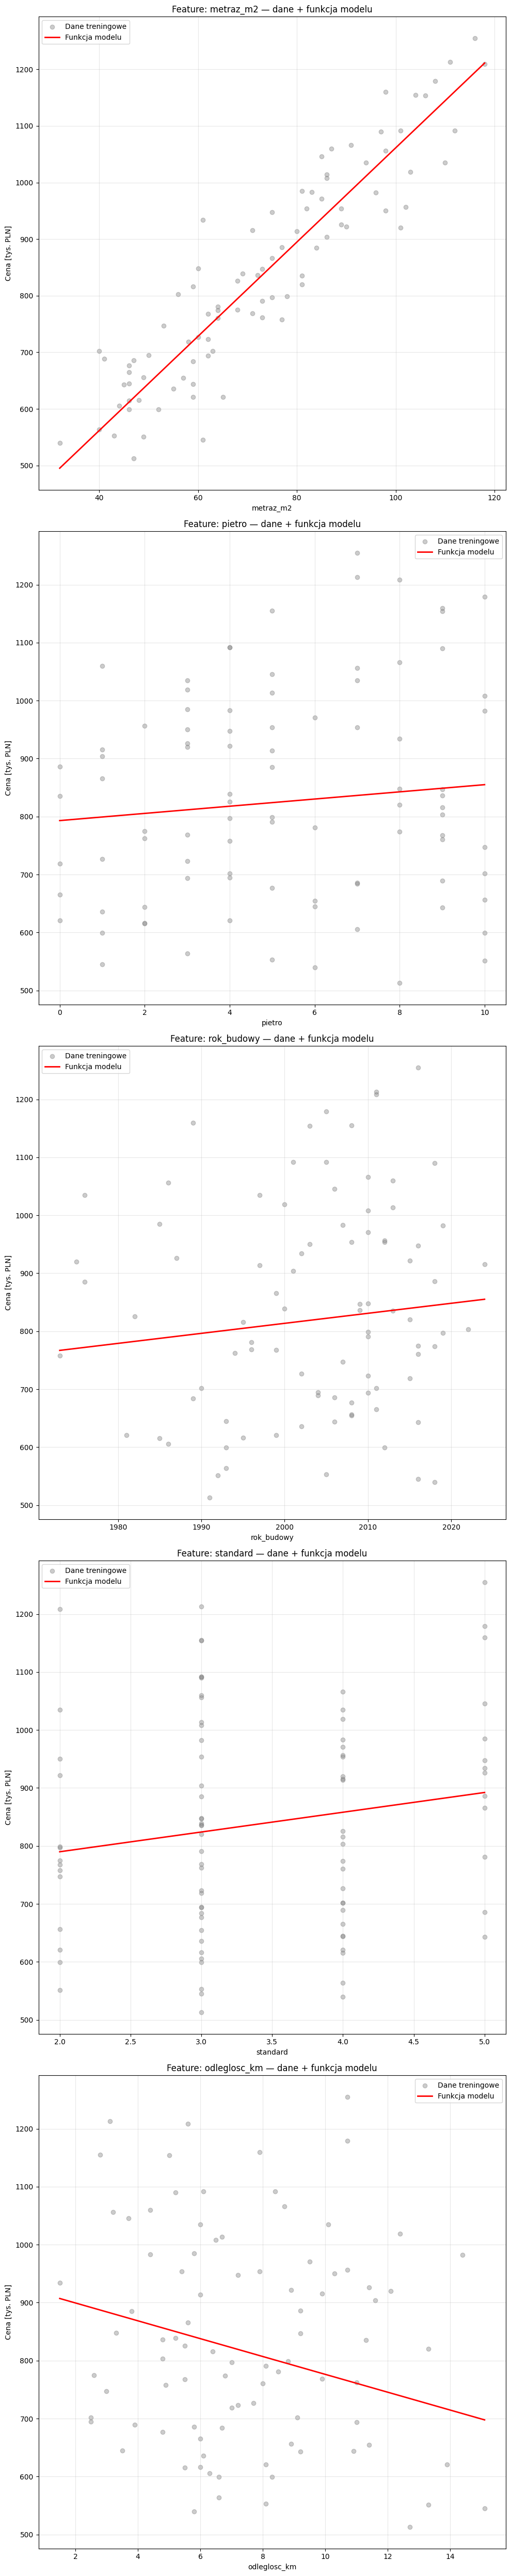

In [30]:
import numpy as np
import matplotlib.pyplot as plt

feature_cols = ['metraz_m2', 'pietro', 'rok_budowy', 'standard', 'odleglosc_km']

# Ustalamy wartości stałe dla pozostałych cech
medians = X_train.median()

n = len(feature_cols)
size = 10
plt.figure(figsize=(size, size * n))

for i, feature in enumerate(feature_cols, 1):

    # Zakres wartości dla tej cechy
    x_range = np.linspace(X_train[feature].min(), X_train[feature].max(), 300)

    # Tworzymy ramkę do predykcji
    X_plot = pd.DataFrame({
        col: (x_range if col == feature else medians[col])
        for col in feature_cols
    })

    # Predykcja modelu
    y_plot = model.predict(X_plot)

    # Subplot
    plt.subplot(n, 1, i)
    plt.scatter(X_train[feature], y_train, alpha=0.4, label="Dane treningowe", color="gray")
    plt.plot(x_range, y_plot, color="red", linewidth=2, label="Funkcja modelu")

    plt.xlabel(feature)
    plt.ylabel("Cena [tys. PLN]")
    plt.title(f"Feature: {feature} — dane + funkcja modelu")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()


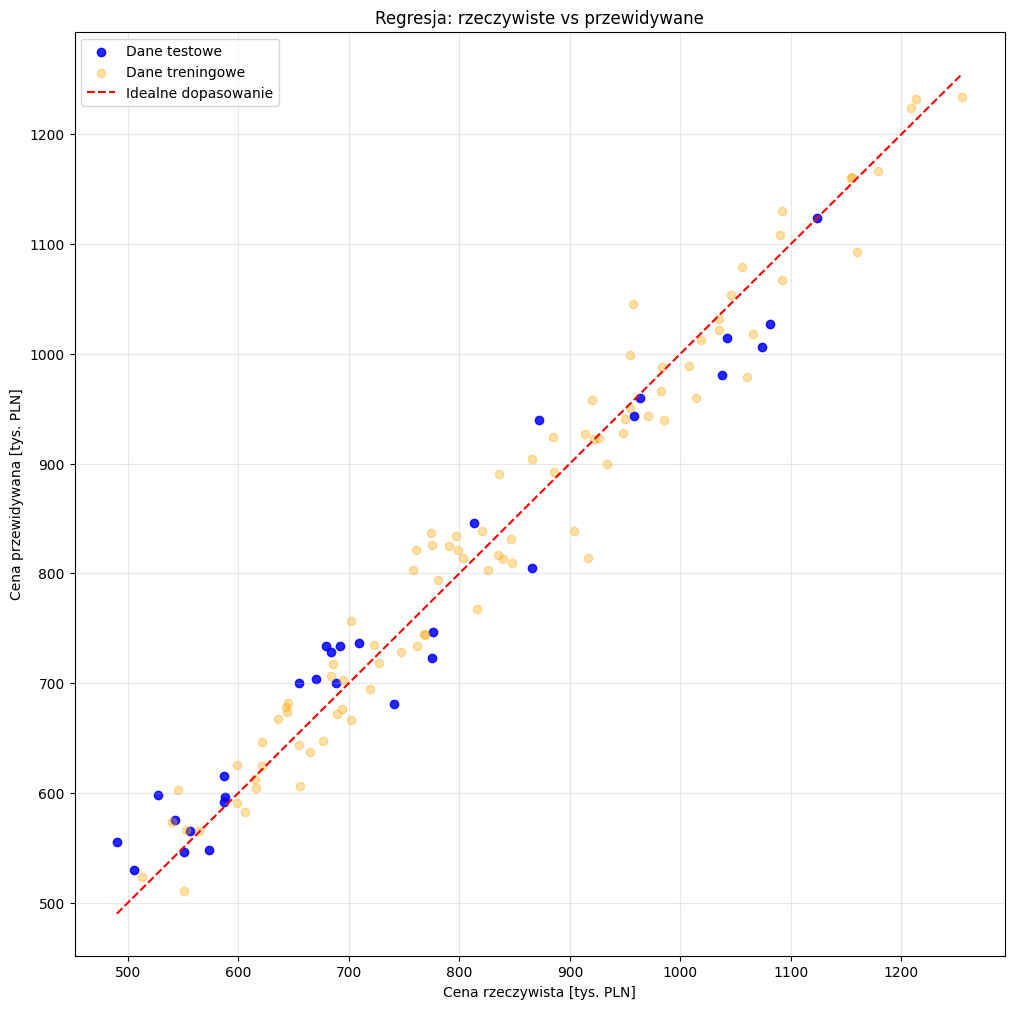

In [31]:
# --- predykcje ---
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

plt.figure(figsize=(12, 12))

# Punkty testowe
plt.scatter(y_test, y_pred, alpha=0.85, label="Dane testowe", color="blue")

# Punkty treningowe
plt.scatter(y_train, y_pred_train, alpha=0.35, label="Dane treningowe", color="orange")

# Linia idealnego dopasowania y = x
min_val = min(y_test.min(), y_pred.min(), y_train.min(), y_pred_train.min())
max_val = max(y_test.max(), y_pred.max(), y_train.max(), y_pred_train.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Idealne dopasowanie")

plt.xlabel("Cena rzeczywista [tys. PLN]")
plt.ylabel("Cena przewidywana [tys. PLN]")
plt.title("Regresja: rzeczywiste vs przewidywane")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 8) Zapisanie modelu do pliku

In [29]:
import pickle

with open("model_cena_mieszkan.pkl", "wb") as f:
    pickle.dump(model, f)
